In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

In [3]:
df = pd.read_csv(r'spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## Preprocessing

In [4]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
df.duplicated().sum()

np.int64(403)

In [6]:
df.drop_duplicates(keep='first', inplace=True)

In [7]:
df.shape

(5169, 2)

In [8]:
df.rename(columns={'v1':'target', 'v2':'message'}, inplace=True)

In [9]:
df

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [10]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\garvc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [12]:
df['characters_length'] = df['message'].apply(lambda x: len(x))
df

,target,message,characters_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [15]:
df['words_length'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
df

,target,message,characters_length,words_length
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27


In [17]:
df['sentence_length'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))
df

,target,message,characters_length,words_length,sentence_length
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [20]:
# 0 -> Not spam, 1 -> Spam
df

,target,message,characters_length,words_length,sentence_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


## EDA

In [23]:
ratio_df = df['target'].value_counts().reset_index()

In [26]:
ratio_df['target'] = ratio_df['target'].map({0 : 'Not Spam', 1 : 'Spam'})

In [31]:
ratio_df['percentage'] = round(ratio_df['count'] / ratio_df['count'].sum() * 100, 2)

In [32]:
ratio_df

,target,count,percentage
0,Not Spam,4516,87.37
1,Spam,653,12.63


In [55]:
px.bar(ratio_df, x='target', y='count', color='target', text='percentage')

In [45]:
df.groupby('target').describe().T

target                             0           1
characters_length count  4516.000000  653.000000
                  mean     70.459256  137.891271
                  std      56.358207   30.137753
                  min       2.000000   13.000000
                  25%      34.000000  132.000000
                  50%      52.000000  149.000000
                  75%      90.000000  157.000000
                  max     910.000000  224.000000
words_length      count  4516.000000  653.000000
                  mean     17.123782   27.667688
                  std      13.493970    7.008418
                  min       1.000000    2.000000
                  25%       8.000000   25.000000
                  50%      13.000000   29.000000
                  75%      22.000000   32.000000
                  max     220.000000   46.000000
sentence_length   count  4516.000000  653.000000
                  mean      1.820195    2.970904
                  std       1.383657    1.488425
                  min       1.000000    1.000000
                  25%       1.000000    2.000000
                  50%       1.000000    3.000000
                  75%       2.000000    4.000000
                  max      38.000000    9.000000

In [53]:
px.histogram(df,x='characters_length', color='target', barmode='overlay', opacity=0.7)

In [54]:
px.histogram(df,x='words_length', color='target', barmode='overlay', opacity=0.7)

<Axes: >

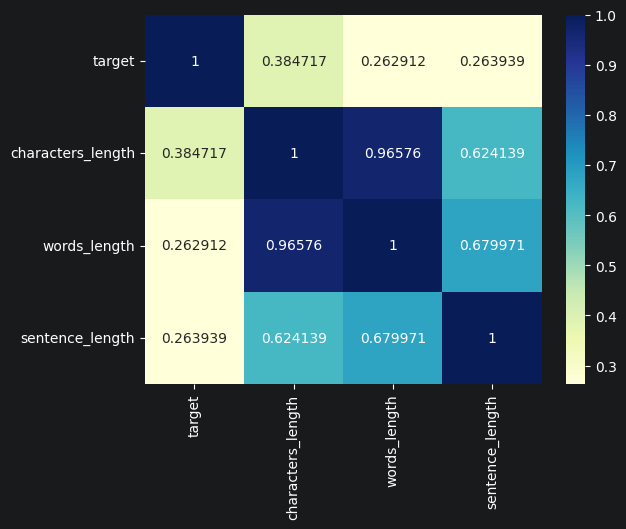

In [60]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='g', cmap='YlGnBu')

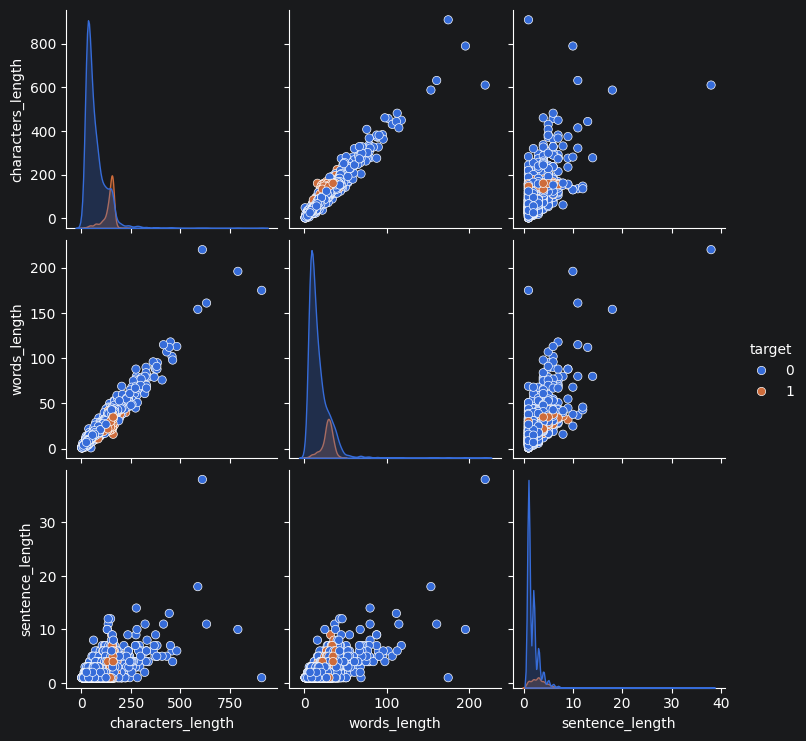

In [58]:
sns.pairplot(df, hue='target')

## Data/Text Preprocessing

In [61]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [65]:
from nltk.corpus import stopwords

In [64]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\garvc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [68]:
from nltk.stem.porter import PorterStemmer

In [69]:
def preprocess(text):
    text = text.lower()

    text = nltk.word_tokenize(text)
    text = [word for word in text if word.isalpha()]
    text = [word for word in text if not word in string.punctuation]
    text = [word for word in text if not word in stopwords.words('english')]

    ps = PorterStemmer()
    text = [ps.stem(word) for word in text]

    return ' '.join(text)

In [70]:
preprocess('Hi! How are you my darling??')

'hi darl'

In [72]:
transformed_text = df['message'].apply(preprocess)
df.insert(1, 'transformed_text', transformed_text)

In [73]:
df

,target,transformed_text,message,characters_length,words_length,sentence_length
0,0,go jurong point crazi avail bugi n great world...,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,ok lar joke wif u oni,Ok lar... Joking wif u oni...,29,8,2
2,1,free entri wkli comp win fa cup final tkt may ...,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,u dun say earli hor u c alreadi say,U dun say so early hor... U c already then say...,49,13,1
4,0,nah think goe usf live around though,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,1,time tri contact u pound prize claim easi call...,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,b go esplanad fr home,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,piti mood suggest,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,guy bitch act like interest buy someth els nex...,The guy did some bitching but I acted like i'd...,125,27,1


In [85]:
from wordcloud import WordCloud
wc = WordCloud(height=500, width=500, min_font_size=10, background_color='white')

In [86]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))

In [87]:
px.imshow(spam_wc)

In [88]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
px.imshow(ham_wc)

['free entri wkli comp win fa cup final tkt may text fa receiv entri question std txt rate c appli',
 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv',
 'winner valu network custom select receivea prize reward claim call claim code valid hour',
 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free',
 'six chanc win cash pound txt send cost tsandc appli repli hl info',
 'urgent week free membership prize jackpot txt word claim c lccltd pobox',
 'xxxmobilemovieclub use credit click wap link next txt messag click http',
 'england v macedonia dont miss news txt ur nation team eg england tri wale scotland',
 'thank subscript rington uk mobil charg pleas confirm repli ye repli charg',
 'rodger burn msg tri call repli sm free nokia mobil free camcord pleas call deliveri tomorrow',
 'sm ac sptv new jersey devil detroit red wing play ice hockey correct incorrect end repli end sptv',
 'congrat year special cinema pass call c suprman v 

In [98]:
all_words = []

for mssg in df[df['target'] == 1]['transformed_text'].to_list():
    for wrd in mssg.split():
        all_words.append(wrd)

all_words

['free',
 'entri',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 'may',
 'text',
 'fa',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 'freemsg',
 'hey',
 'darl',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'valid',
 'hour',
 'mobil',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 'six',
 'chanc',
 'win',
 'cash',
 'pound',
 'txt',
 'send',
 'cost',
 'tsandc',
 'appli',
 'repli',
 'hl',
 'info',
 'urgent',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 'c',
 'lccltd',
 'pobox',
 'xxxmobilemovieclub',
 'use',
 'credit',
 'click',
 'wap',
 'link',
 'next',
 'txt',
 'messag',
 'click',
 'http',
 'england',
 'v',
 'macedonia',
 'do

In [102]:
from collections import Counter
spam_freq_wrds = pd.DataFrame(Counter(all_words).most_common(30)).rename(columns={0:'word', 1:'count'})

In [103]:
px.bar(spam_freq_wrds, x='word', y='count', color='word', text='count')

In [104]:
all_words = []

for mssg in df[df['target'] == 0]['transformed_text'].to_list():
    for wrd in mssg.split():
        all_words.append(wrd)

all_words

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'way',
 'u',
 '

In [105]:
ham_freq_wrds = pd.DataFrame(Counter(all_words).most_common(30)).rename(columns={0:'word', 1:'count'})

In [106]:
px.bar(ham_freq_wrds, x='word', y='count', color='word', text='count')